# Generating RBS Calculator Data and Validation
In  this notebook, we demonstrate sampling approaches to generating synthetic consignments from RBS calculator data

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np


In [ ]:
datadir = Path("data/fake_pis_data.csv")    
df = pd.read_csv(datadir)
df = df.dropna()

# Note: CSV now includes CREATED_DATETIME and PRODUCER columns (added in 2025)
# These are available for temporal and supplier analysis but not used in synthetic generation
print(f"Loaded PIS data: {len(df)} records, {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-6127,Miami PIS,Sea,Japan,"Root cutting, crown, or clump, Tuberous Root",263,18879,Rocket Farms
1,INS-8544,Miami PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",46,470,White's Nursery & Greenhouses Inc.
2,INS-6098,Miami PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",25,5,Grower Direct Farms
3,INS-6636,Miami PIS,Sea,New Zeland,Meristem or Callus Tissue Culture (micropropag...,506,24161,DeLeon's Bromeliads
4,INS-3963,Miami PIS,Train,Japan,"Root cutting, crown, or clump, Tuberous Root",148,1859,Ocean Breeze International
...,...,...,...,...,...,...,...,...
493,INS-1079,Atlanta PIS,Air,Japan,"Root cutting, crown, or clump, Tuberous Root",443,16321,Kent's Bromeliads Nursery Inc.
494,INS-7205,Atlanta PIS,Sea,New Zeland,Budwood/Graftwood (scion),332,16067,Delray Plants Inc.
495,INS-2328,Atlanta PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",980,33721,Colorama Wholesale Nursery
496,INS-3945,Atlanta PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,392,23391,Henry Mast Greenhouses/Masterpiece Flower Co LLC


In [5]:
# Naive approach (baseline)

def multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    sampled = {}
    for col in columns:
        values, counts = np.unique(df[col], return_counts=True)
        probs = counts / counts.sum()
        sampled[col] = np.random.choice(values, size=n_samples, p=probs)
    return pd.DataFrame(sampled)

In [ ]:
cols = [
    'INSPECTION_NUMBER',
    'INSPECTION_LOCATION_NAME', 
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
    'PRODUCER',
]
sampled_df = multinomial_sample(df, columns=cols, n_samples=5000, random_state=42)
sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-4386,Los Angeles PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,77,27131,Northwest Horticulture
1,INS-9555,Miami PIS,Air,Netherlands,Budwood/Graftwood (scion),52,15475,Altman Plants
2,INS-7546,Miami PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",605,75120,Northwest Horticulture
3,INS-6494,Los Angeles PIS,Sea,India,Meristem or Callus Tissue Culture (micropropag...,963,5605,Battlefield Farms
4,INS-2328,Miami PIS,Air,India,"Bulb, Corm, Rhizome, Tuberous Stem",500,23575,Paul Ecke Ranch
...,...,...,...,...,...,...,...,...
4995,INS-9111,Miami PIS,Sea,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",952,14646,Polk Nursery Company Inc.
4996,INS-1976,Miami PIS,Air,India,Meristem or Callus Tissue Culture (micropropag...,754,15592,Rocket Farms
4997,INS-3964,Miami PIS,Air,Japan,"Root cutting, crown, or clump, Tuberous Root",12,19235,Dewar Nurseries
4998,INS-8477,Los Angeles PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,382,75205,Henry Mast Greenhouses/Masterpiece Flower Co LLC


In [7]:
def sequential_multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    samples = []
    for _ in range(n_samples):
        subset = df
        sample = {}
        for col in columns:
            values, counts = np.unique(subset[col], return_counts=True)
            probs = counts / counts.sum()
            chosen = np.random.choice(values, p=probs)
            sample[col] = chosen
            subset = subset[subset[col] == chosen]
            if subset.empty:
                # If no rows left, break and sample from original df for remaining columns
                for rem_col in columns[len(sample):]:
                    values, counts = np.unique(df[rem_col], return_counts=True)
                    probs = counts / counts.sum()
                    sample[rem_col] = np.random.choice(values, p=probs)
                break
        samples.append(sample)
    return pd.DataFrame(samples)


In [8]:
sequential_sampled_df = sequential_multinomial_sample(df, columns=cols, n_samples=5000, random_state=42)
sequential_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-4386,Miami PIS,Sea,Netherlands,"Root cutting, crown, or clump, Tuberous Root",19,300,Sawyer Nursery
1,INS-6498,Miami PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",544,31596,Kawahara Nurseries
2,INS-3818,Miami PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,789,36930,California Pajarosa
3,INS-4976,Miami PIS,Sea,India,Meristem or Callus Tissue Culture (micropropag...,278,16679,Gallup & Stribling Orchids Inc.
4,INS-1508,Atlanta PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",297,1984,DeLeon's Bromeliads
...,...,...,...,...,...,...,...,...
4995,INS-1712,Miami PIS,Air,New Zeland,Meristem or Callus Tissue Culture (micropropag...,119,153,Hermann Engelmann Greenhouses
4996,INS-2582,Atlanta PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",577,31405,Bob's Market & Greenhouses Inc.
4997,INS-3993,Miami PIS,Train,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",717,30272,Timberline Nursery Inc.
4998,INS-1145,Los Angeles PIS,Air,India,Budwood/Graftwood (scion),781,31662,Bob's Market & Greenhouses Inc.


In [9]:
from sklearn.mixture import GaussianMixture

def gmm_sample(df, columns, n_samples=1, random_state=None, n_components=3):
    # Only works for numeric columns
    numeric_cols = [col for col in columns if np.issubdtype(df[col].dtype, np.number)]
    cat_cols = [col for col in columns if col not in numeric_cols]
    
    # Fit GMM on numeric columns
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(df[numeric_cols])
    sampled_numeric, _ = gmm.sample(n_samples)
    sampled_numeric = pd.DataFrame(sampled_numeric, columns=numeric_cols)
    # Round and cast to int for count columns
    for col in numeric_cols:
        sampled_numeric[col] = np.round(sampled_numeric[col]).astype(int)
        # Clip to observed min/max
        sampled_numeric[col] = sampled_numeric[col].clip(df[col].min(), df[col].max())
    
    # For categorical columns, sample independently as in naive
    sampled_cat = {}
    for col in cat_cols:
        values, counts = np.unique(df[col], return_counts=True)
        probs = counts / counts.sum()
        sampled_cat[col] = np.random.choice(values, size=n_samples, p=probs)
    sampled_cat = pd.DataFrame(sampled_cat)
    
    # Combine
    sampled = pd.concat([sampled_cat, sampled_numeric], axis=1)
    # Reorder columns to match input
    sampled = sampled[columns]
    return sampled


In [10]:
gmm_sampled_df = gmm_sample(df, columns=cols, n_samples=5000, random_state=42, n_components=3)
gmm_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-3737,Los Angeles PIS,Sea,India,Meristem or Callus Tissue Culture (micropropag...,746,18414,Johannes Flowers Inc.
1,INS-1805,Miami PIS,Air,India,"Root cutting, crown, or clump, Tuberous Root",416,5465,Four Star Greenhouses
2,INS-2055,Miami PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",171,5509,Plant Marketing LLC
3,INS-2463,Miami PIS,Sea,India,"Bulb, Corm, Rhizome, Tuberous Stem",1,9975,Bob's Market & Greenhouses Inc.
4,INS-2812,Los Angeles PIS,Air,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",1,5,Polk Nursery Company Inc.
...,...,...,...,...,...,...,...,...
4995,INS-2620,Miami PIS,Air,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",344,13121,Milgro Nursery Inc.
4996,INS-3930,Los Angeles PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",771,37643,Wenke Greenhouses
4997,INS-4122,Miami PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,507,26098,Van de Wetering Greenhouses Inc.
4998,INS-3615,Miami PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,596,26895,"Costa Farms, LLC"


In [11]:
from sklearn.mixture import GaussianMixture

def gmm_mns_sample(df, columns, n_samples=1, random_state=None, n_components=3):
    # Only works for numeric columns
    numeric_cols = [col for col in columns if np.issubdtype(df[col].dtype, np.number)]
    cat_cols = [col for col in columns if col not in numeric_cols]
    
    # Fit GMM on numeric columns
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(df[numeric_cols])
    sampled_numeric, _ = gmm.sample(n_samples)
    sampled_numeric = pd.DataFrame(sampled_numeric, columns=numeric_cols)
    # Round and cast to int for count columns
    for col in numeric_cols:
        sampled_numeric[col] = np.round(sampled_numeric[col]).astype(int)
        # Clip to observed min/max
        sampled_numeric[col] = sampled_numeric[col].clip(df[col].min(), df[col].max())
    
    # For categorical columns, sample using multinomial sample
    sampled_cat = []
    for _ in range(n_samples):
        subset = df
        sample = {}
        for col in cat_cols:
            values, counts = np.unique(subset[col], return_counts=True)
            probs = counts / counts.sum()
            chosen = np.random.choice(values, p=probs)
            sample[col] = chosen
            subset = subset[subset[col] == chosen]
            if subset.empty:
                # If no rows left, break and sample from original df for remaining columns
                for rem_col in columns[len(sample):]:
                    values, counts = np.unique(df[rem_col], return_counts=True)
                    probs = counts / counts.sum()
                    sample[rem_col] = np.random.choice(values, p=probs)
                break
        sampled_cat.append(sample)
    sampled_cat = pd.DataFrame(sampled_cat)
    
    # Combine
    sampled = pd.concat([sampled_cat, sampled_numeric], axis=1)
    # Reorder columns to match input
    sampled = sampled[columns]
    return sampled


In [12]:
gmm_mns_sampled_df = gmm_mns_sample(df, columns=cols, n_samples=5000, random_state=42, n_components=3)
gmm_mns_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-1298,Miami PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,746,18414,Operation
1,INS-9821,Atlanta PIS,Air,New Zeland,Budwood/Graftwood (scion),416,5465,Van Wingerden International Inc.
2,INS-1230,Miami PIS,Sea,Netherlands,Meristem or Callus Tissue Culture (micropropag...,171,5509,Operation
3,INS-6260,Miami PIS,Air,India,"Bulb, Corm, Rhizome, Tuberous Stem",1,9975,Barcelo Enterprises
4,INS-1232,Miami PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,1,5,Kerry's Bromeliads
...,...,...,...,...,...,...,...,...
4995,INS-1721,Miami PIS,Train,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",344,13121,Gallup & Stribling Orchids Inc.
4996,INS-8926,Atlanta PIS,Air,India,Budwood/Graftwood (scion),771,37643,"Olive Hill Greenhouses, Inc."
4997,INS-3930,Miami PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",507,26098,Operation
4998,INS-3686,Atlanta PIS,Air,Japan,"Root cutting, crown, or clump, Tuberous Root",596,26895,Smith Gardens


In [17]:
from scipy.stats import wasserstein_distance, wasserstein_distance_nd

# Compute Wasserstein distance for 'TOTAL_SAMPLING_UNITS' grouped by 'INSPECTION_LOCATION_NAME'
locations = df['INSPECTION_LOCATION_NAME'].unique()
calc_cols = [
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
]

wasserstein_dict = {}
for col in calc_cols:
    wasserstein_results = []
    for loc in locations:
        orig = df[df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        naive = sampled_df[sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        seq = sequential_sampled_df[sequential_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        gmm = gmm_sampled_df[gmm_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        gmm_mns = gmm_mns_sampled_df[gmm_mns_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
        w_naive = wasserstein_distance(orig, naive)
        w_seq = wasserstein_distance(orig, seq)
        w_gmm = wasserstein_distance(orig, gmm)
        w_gmm_mns = wasserstein_distance(orig, gmm_mns)
        wasserstein_results.append({
            'INSPECTION_LOCATION_NAME': loc,
            'wasserstein_naive': w_naive,
            'wasserstein_sequential': w_seq,
            'wasserstein_gaussian': w_gmm,
            'wasserstein_hybrid': w_gmm_mns,

        })
    wasserstein_dict[col] = wasserstein_results

wasserstein_df = pd.DataFrame(wasserstein_results)
wasserstein_df

,INSPECTION_LOCATION_NAME,wasserstein_naive,wasserstein_sequential,wasserstein_gaussian,wasserstein_hybrid
0,Miami PIS,25.673618,9.139799,37.573356,36.354072
1,Los Angeles PIS,20.215263,12.532195,24.650837,31.046071
2,Atlanta PIS,43.819216,15.633598,56.483495,62.149181


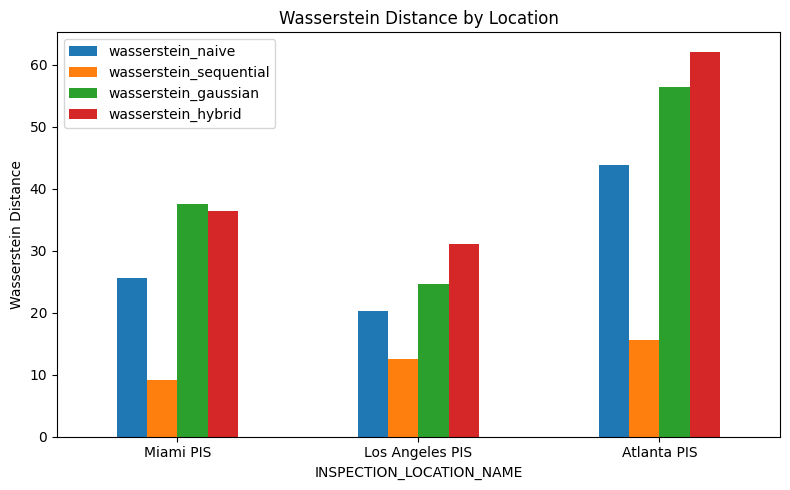

In [18]:
import matplotlib.pyplot as plt

wasserstein_df.plot(
    x='INSPECTION_LOCATION_NAME',
    y=['wasserstein_naive', 'wasserstein_sequential','wasserstein_gaussian','wasserstein_hybrid'],
    kind='bar',
    figsize=(8, 5)
)
plt.ylabel('Wasserstein Distance')
plt.title('Wasserstein Distance by Location')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

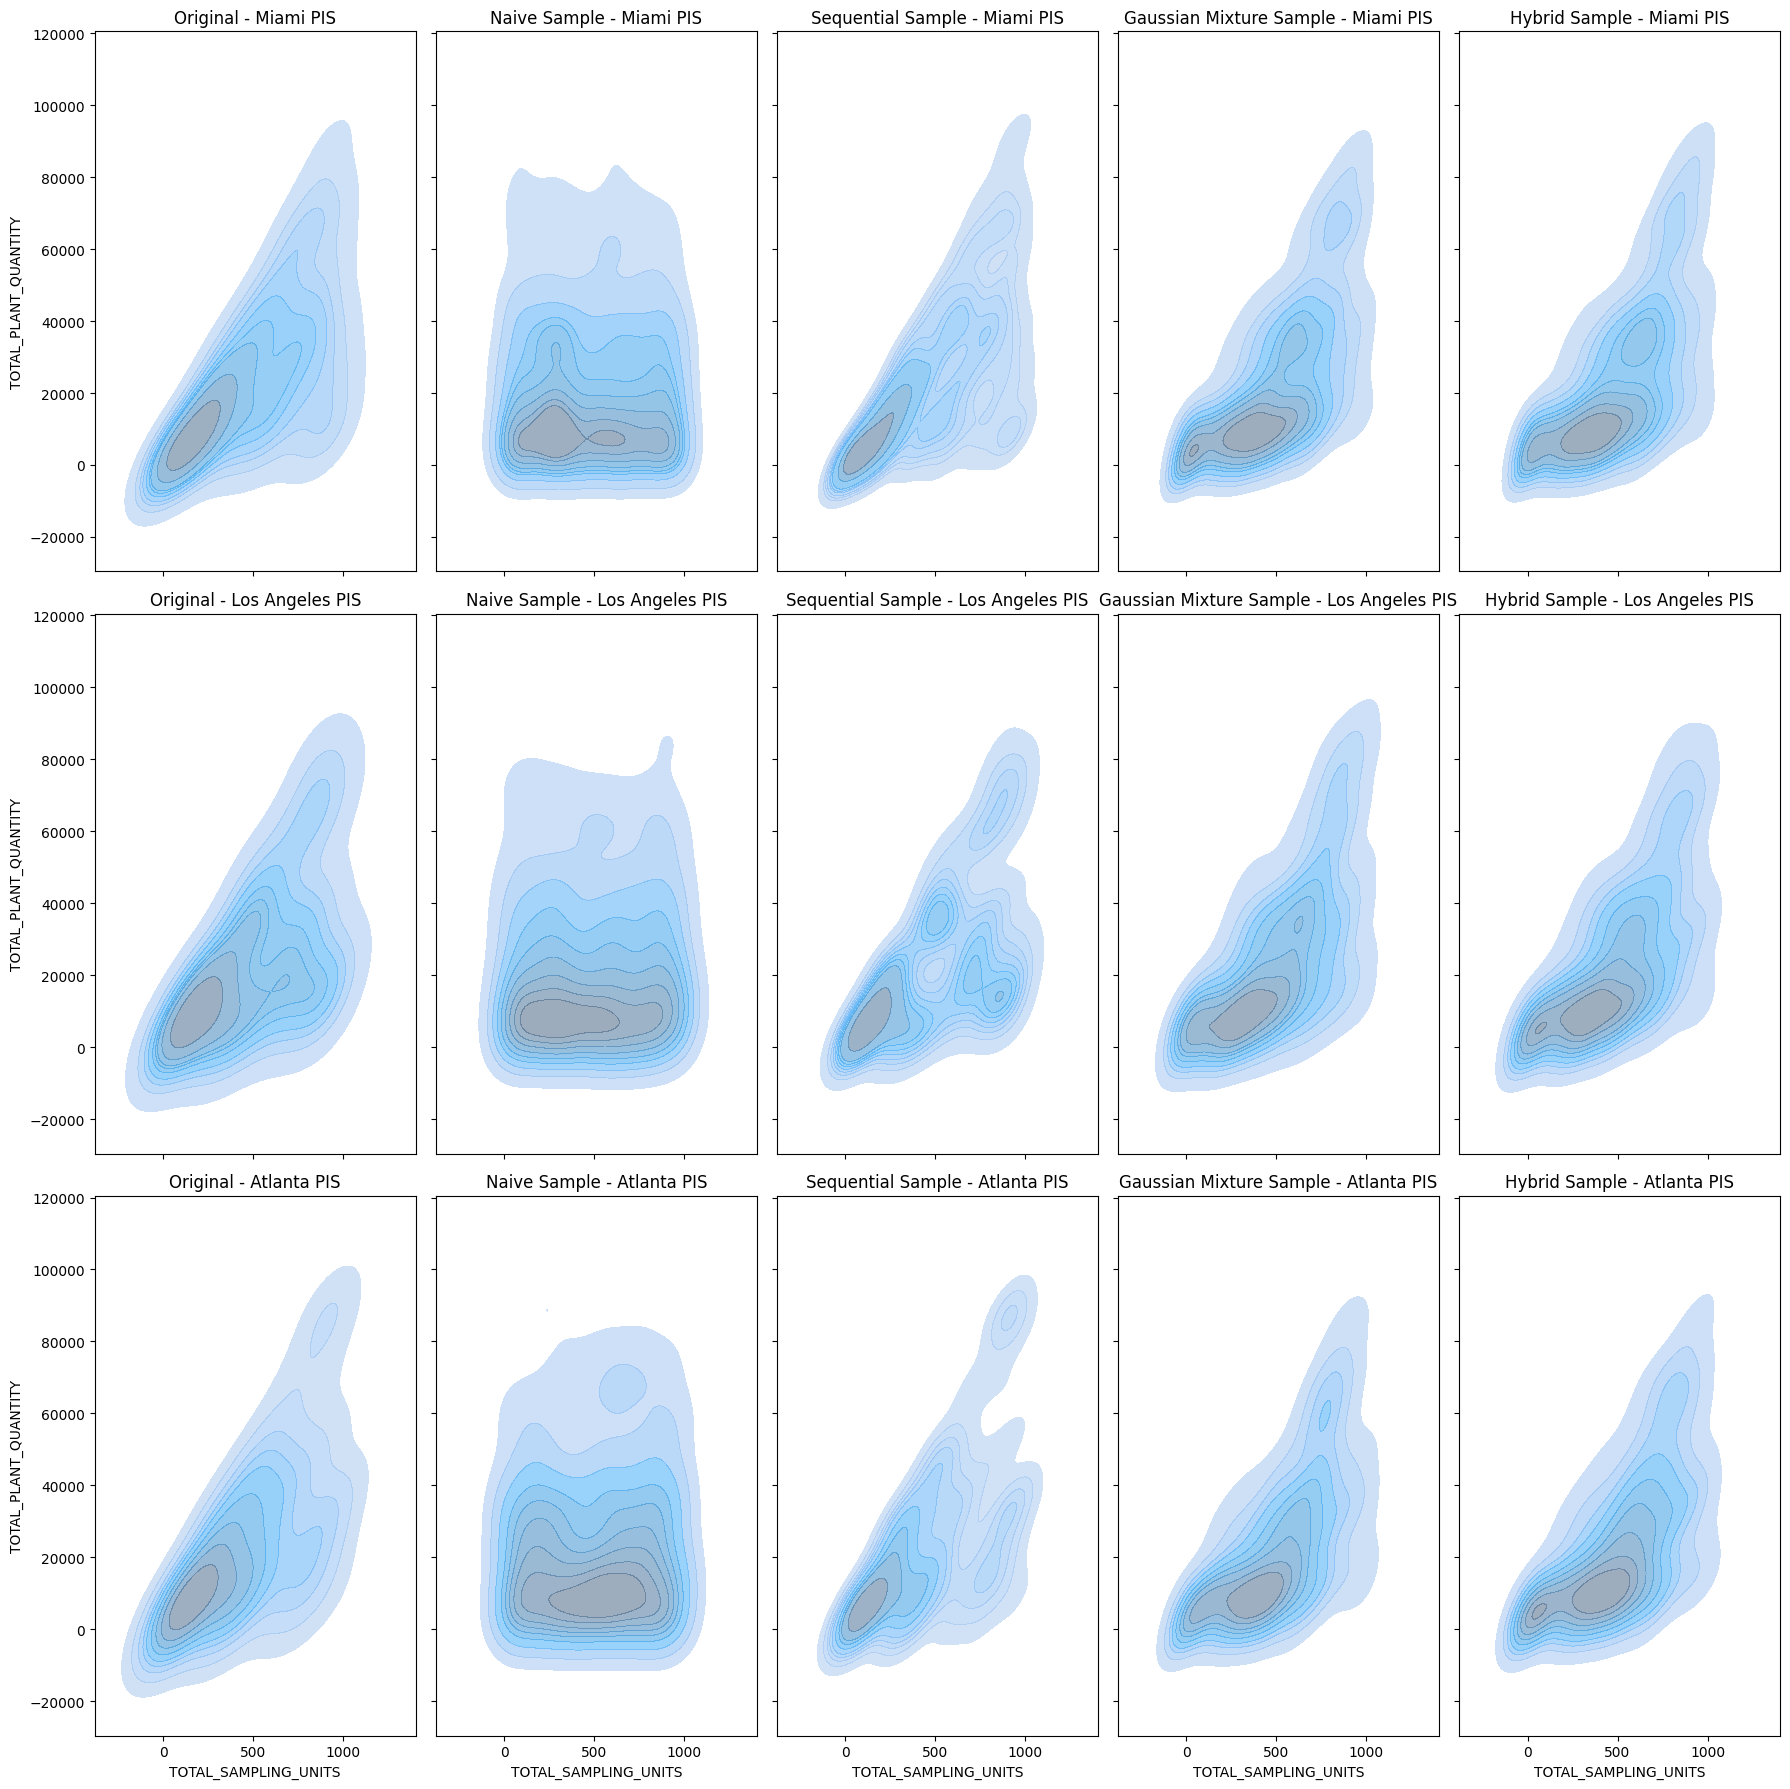

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare a list of unique PIS stations
pis_stations = df['INSPECTION_LOCATION_NAME'].unique()
datasets = [
    (df, "Original"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample"),
    (gmm_mns_sampled_df, "Hybrid Sample"),
]

fig, axes = plt.subplots(len(pis_stations), len(datasets), figsize=(18, 6 * len(pis_stations)), sharex=True, sharey=True)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j] if len(pis_stations) > 1 else axes[j]
        subset = data[data['INSPECTION_LOCATION_NAME'] == pis]
        if not subset.empty:
            sns.kdeplot(
                data=subset,
                x="TOTAL_SAMPLING_UNITS",
                y="TOTAL_PLANT_QUANTITY",
                fill=True,
                ax=ax,
                thresh=0.05,
                alpha=0.5
            )
        ax.set_title(f"{title} - {pis}")
        ax.set_xlabel("TOTAL_SAMPLING_UNITS")
        ax.set_ylabel("TOTAL_PLANT_QUANTITY")

plt.tight_layout()
plt.show()

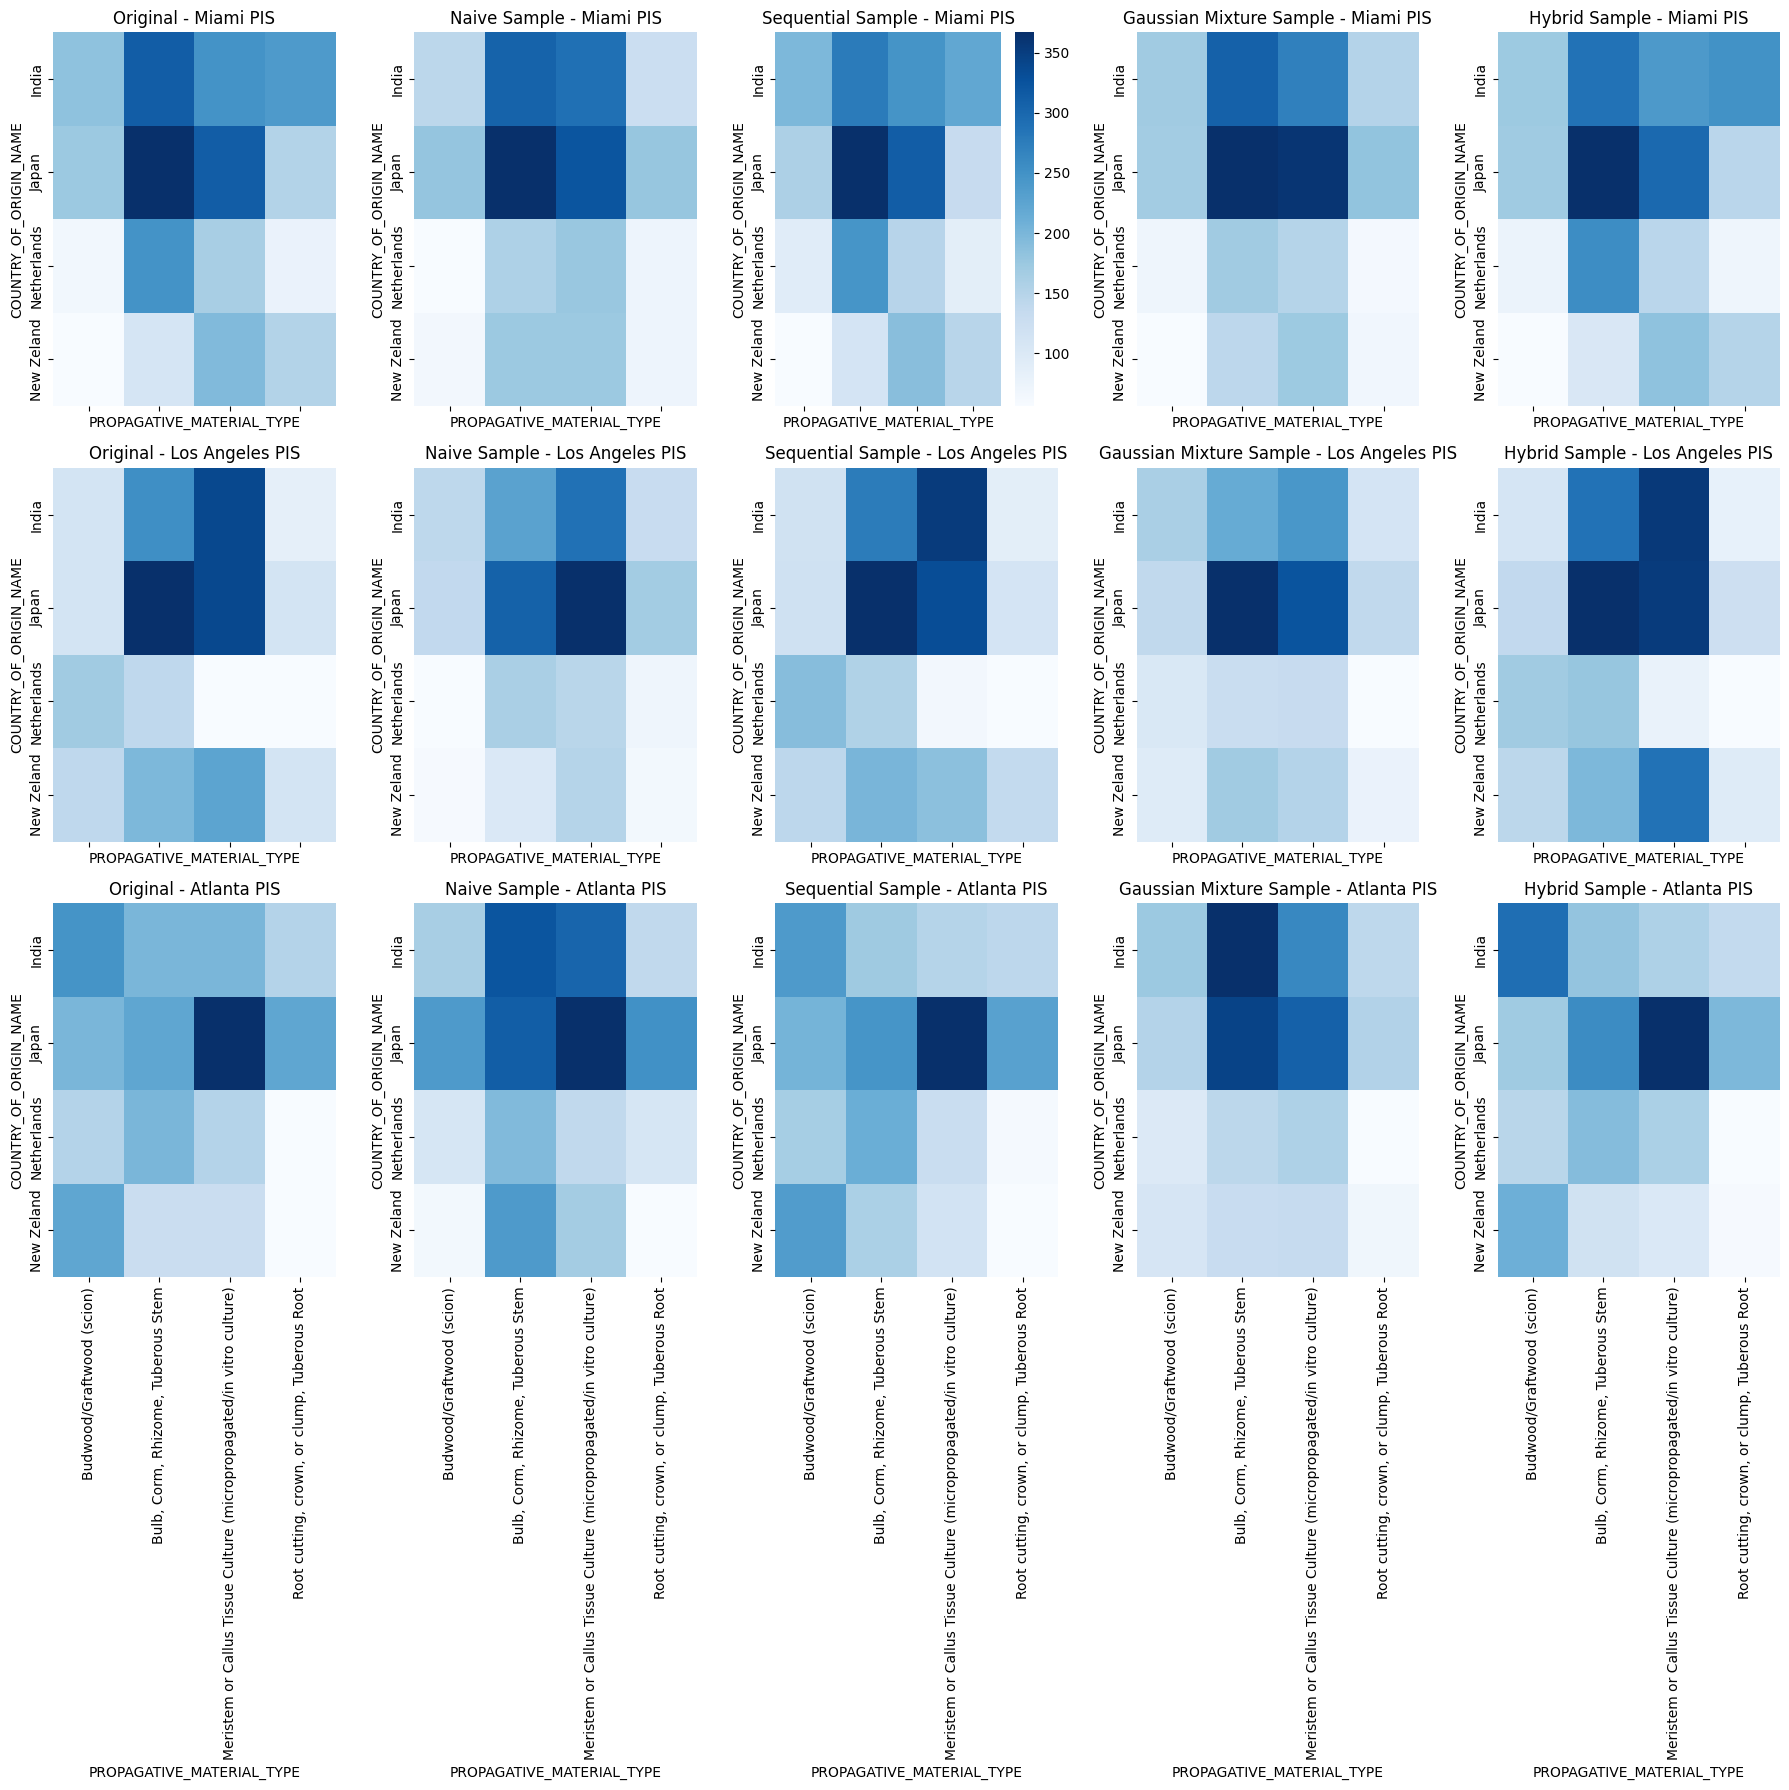

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


# Prepare a list of unique PIS stations
pis_stations = df['INSPECTION_LOCATION_NAME'].unique()
datasets = [
    (df, "Original"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample"),
    (gmm_mns_sampled_df, "Hybrid Sample"),
]
fig, axes = plt.subplots(len(pis_stations), len(datasets), figsize=(18, 6 * len(pis_stations)), sharex=True)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j] if len(pis_stations) > 1 else axes[j]
        subset = data[data['INSPECTION_LOCATION_NAME'] == pis]
        if not subset.empty:
            # Create a pivot table of counts
            pivot = subset.pivot_table(
                index="COUNTRY_OF_ORIGIN_NAME",
                columns="PROPAGATIVE_MATERIAL_TYPE",
                aggfunc="size",
                fill_value=0
            )
            sns.heatmap(
                pivot,
                cmap="Blues",
                ax=ax,
                cbar=(i == 0 and j == 2)  # Only show colorbar on the last plot of the first row
            )
        ax.set_title(f"{title} - {pis}")
        ax.set_xlabel("PROPAGATIVE_MATERIAL_TYPE")
        ax.set_ylabel("COUNTRY_OF_ORIGIN_NAME")

plt.tight_layout()
plt.show()

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

group_col = 'INSPECTION_LOCATION_NAME'
locations = df[group_col].dropna().unique()

calc_cols = [
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
]

discrete_cols = {
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
}

rows = []

for col in calc_cols:
    col_is_discrete = col in discrete_cols

    for loc in locations:
        orig = df.loc[df[group_col] == loc, col].dropna()
        naive = sampled_df.loc[sampled_df[group_col] == loc, col].dropna()
        seq = sequential_sampled_df.loc[sequential_sampled_df[group_col] == loc, col].dropna()
        gmm = gmm_sampled_df.loc[gmm_sampled_df[group_col] == loc, col].dropna() 
        gmm_mns = gmm_mns_sampled_df.loc[gmm_mns_sampled_df[group_col] == loc, col].dropna() 

        if len(orig) == 0:
            w_naive = w_seq = w_gmm = w_gmm_mns =  np.nan
        else:
            if col_is_discrete:
                # CATEGORICAL/OBJECT DISCRETE (uses alphabetical order to impose a metric)
                cats = pd.Index(pd.unique(pd.concat([
                    orig.astype("string"),
                    naive.astype("string"),
                    seq.astype("string"),
                    gmm.astype("string"),
                    gmm_mns.astype("string"),
                ]))).sort_values()

                enc = lambda s: pd.Categorical(s.astype("string"), categories=cats, ordered=True).codes
                oa, on, os, og, oh = map(enc, (orig, naive, seq, gmm, gmm_mns))

                # turn to supports + weights
                va, vn, vs, vg, vh = map(pd.Series, (oa, on, os, og, oh))
                sa, wa = va.value_counts().sort_index().index.to_numpy(), va.value_counts().sort_index().values.astype(float)
                sn, wn = vn.value_counts().sort_index().index.to_numpy(), vn.value_counts().sort_index().values.astype(float)
                ss, ws = vs.value_counts().sort_index().index.to_numpy(), vs.value_counts().sort_index().values.astype(float)
                sg, wg = vg.value_counts().sort_index().index.to_numpy(), vg.value_counts().sort_index().values.astype(float)
                sh, wh = vh.value_counts().sort_index().index.to_numpy(), vh.value_counts().sort_index().values.astype(float)

                w_naive = wasserstein_distance(sa, sn, u_weights=wa, v_weights=wn) if len(naive) else np.nan
                w_seq   = wasserstein_distance(sa, ss, u_weights=wa, v_weights=ws) if len(seq) else np.nan
                w_gmm   = wasserstein_distance(sa, sg, u_weights=wa, v_weights=wg) if len(gmm) else np.nan
                w_gmm_mns   = wasserstein_distance(sa, sh, u_weights=wa, v_weights=wh) if len(gmm_mns) else np.nan

            else:
                # CONTINUOUS
                tofloat = lambda s: s.astype(float).to_numpy()
                oa = tofloat(orig)
                w_naive = wasserstein_distance(oa, tofloat(naive)) if len(naive) else np.nan
                w_seq   = wasserstein_distance(oa, tofloat(seq))   if len(seq) else np.nan
                w_gmm   = wasserstein_distance(oa, tofloat(gmm))   if len(gmm) else np.nan
                w_gmm_mns   = wasserstein_distance(oa, tofloat(gmm_mns))   if len(gmm_mns) else np.nan

        rows.append({
            group_col: loc,
            'column': col,
            'is_discrete': col_is_discrete,
            'wasserstein_naive': w_naive,
            'wasserstein_sequential': w_seq,
            'wasserstein_gaussian': w_gmm,
            'wasserstein_hybrid': w_gmm_mns,
        })

wasserstein_df = pd.DataFrame(rows)
wasserstein_df


,INSPECTION_LOCATION_NAME,column,is_discrete,wasserstein_naive,wasserstein_sequential,wasserstein_gaussian,wasserstein_hybrid
0,Miami PIS,PATHWAY,True,0.090200,0.020020,0.068963,0.019892
1,Los Angeles PIS,PATHWAY,True,0.271576,0.011707,0.255457,0.048373
2,Atlanta PIS,PATHWAY,True,0.384314,0.007870,0.365049,0.006754
3,Miami PIS,COUNTRY_OF_ORIGIN_NAME,True,0.063572,0.011316,0.044420,0.004025
4,Los Angeles PIS,COUNTRY_OF_ORIGIN_NAME,True,0.087364,0.019756,0.058219,0.005992
5,Atlanta PIS,COUNTRY_OF_ORIGIN_NAME,True,0.042157,0.077023,0.047573,0.026653
6,Miami PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.050514,0.021262,0.050903,0.010378
7,Los Angeles PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.125183,0.027073,0.054081,0.030556
8,Atlanta PIS,PROPAGATIVE_MATERIAL_TYPE,True,0.171373,0.043639,0.122039,0.048119
9,Miami PIS,TOTAL_SAMPLING_UNITS,False,25.673618,9.139799,37.573356,36.354072


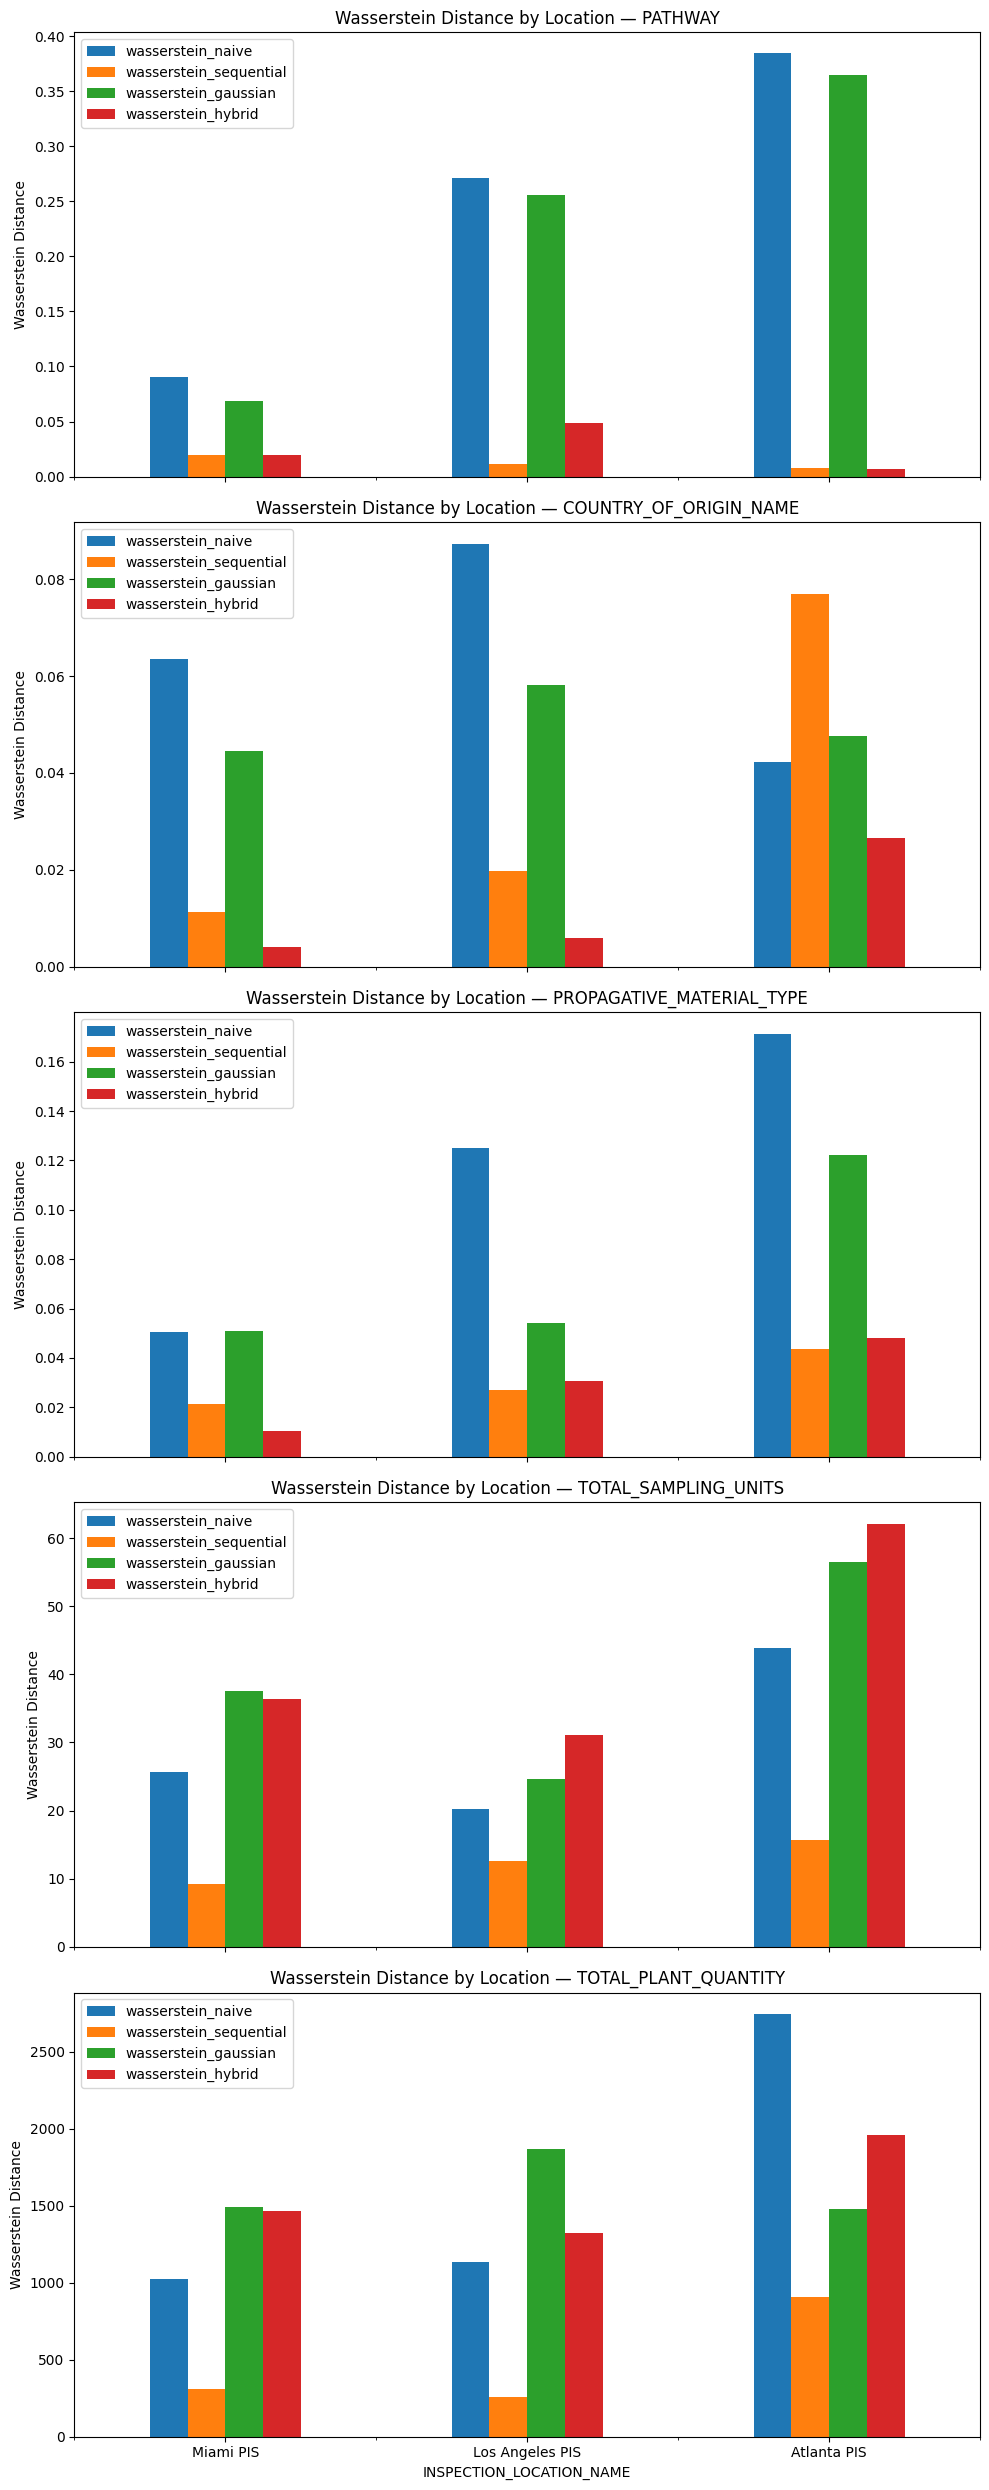

In [26]:
import matplotlib.pyplot as plt

# unique variables (your "column" field in wasserstein_df)
vars_ = wasserstein_df['column'].unique()
n_vars = len(vars_)

fig, axes = plt.subplots(n_vars, 1, figsize=(10, 5 * n_vars), sharex=True)

if n_vars == 1:
    axes = [axes]  # make iterable if only one facet

for ax, var in zip(axes, vars_):
    sub = wasserstein_df[wasserstein_df['column'] == var]

    sub.plot(
        x='INSPECTION_LOCATION_NAME',
        y=['wasserstein_naive', 'wasserstein_sequential', 'wasserstein_gaussian','wasserstein_hybrid'],
        kind='bar',
        ax=ax,
    )
    ax.set_ylabel('Wasserstein Distance')
    ax.set_title(f'Wasserstein Distance by Location — {var}')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


